## Session 9 MLE 13-3-2026 Unsupervised Learning

### K-Mean Clustering Algorthim

#### start

##### 1-Number of cluster K
##### 2- Centroid ---------------------------------|
##### 3- Distance Objects of Centroids-------------|-------> No object move Group |--> End
##### 4- Grouping Based on minimum Distance--------|



In [126]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [127]:
df = pd.read_csv('income.csv')

In [128]:
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


Text(0, 0.5, 'Income($)')

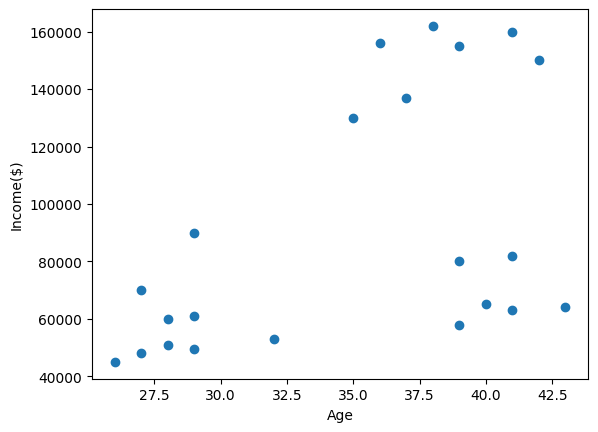

In [129]:
plt.scatter(df.Age , df['Income($)'])
plt.xlabel('Age')
plt.ylabel('Income($)')

In [130]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Age' , 'Income($)']])

y_predicted

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [131]:
df['cluster'] = y_predicted
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,2
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


In [132]:
km.cluster_centers_

array([[3.29090909e+01, 5.61363636e+04],
       [3.82857143e+01, 1.50000000e+05],
       [3.40000000e+01, 8.05000000e+04]])

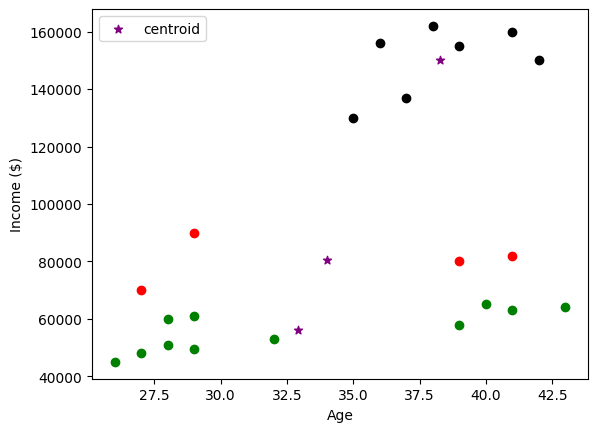

In [133]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.scatter(df1.Age , df1['Income($)'] , color='green')
plt.scatter(df2.Age , df2['Income($)'], color='black')
plt.scatter(df3.Age , df3['Income($)'], color='red')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.legend()
plt.show()

In [134]:
scaler = MinMaxScaler()
scaler.fit(df[["Income($)"]])
df['Income($)'] = scaler.transform(df[["Income($)"]])
scaler.fit(df[["Age"]])
df["Age"] = scaler.transform(df[["Age"]])


In [135]:
km_1 = KMeans(n_clusters=3)
y_predicted_1 = km_1.fit_predict(df[["Age" , "Income($)"]])

y_predicted_1

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [136]:
km_1.cluster_centers_ 


array([[0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ],
       [0.85294118, 0.2022792 ]])

In [137]:
df['cluster_1'] = y_predicted_1
df.head()

,Name,Age,Income($),cluster,cluster_1
0,Rob,0.058824,0.213675,2,0
1,Michael,0.176471,0.384615,2,0
2,Mohan,0.176471,0.136752,0,0
3,Ismail,0.117647,0.128205,0,0
4,Kory,0.941176,0.897436,1,1


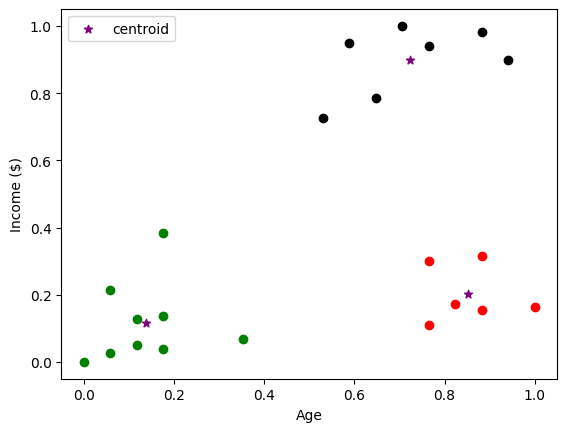

In [138]:
df1 = df[df.cluster_1 == 0]
df2 = df[df.cluster_1 == 1]
df3 = df[df.cluster_1 == 2]

plt.scatter(df1.Age , df1['Income($)'] , color='green')
plt.scatter(df2.Age , df2['Income($)'], color='black')
plt.scatter(df3.Age , df3['Income($)'], color='red')
plt.scatter(km_1.cluster_centers_[:,0],km_1.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.legend()
plt.show()

In [139]:
sse = []

k_rng = range(1,10)

for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['Age' , 'Income($)']])
    sse.append(km.inertia_)



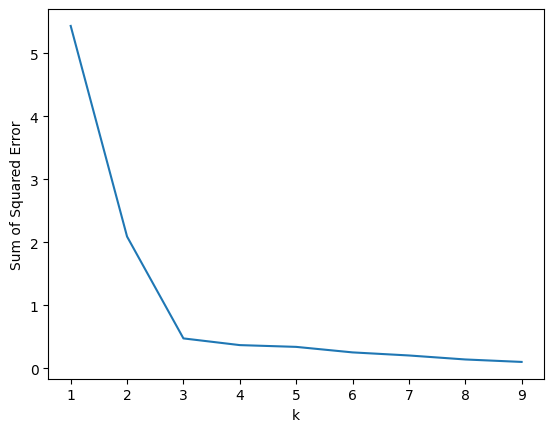

In [141]:
plt.xlabel('k')
plt.ylabel('Sum of Squared Error')
plt.plot(k_rng, sse)

# Hirearchal Cluster